<!-- [reviewer-header] auto-generated; safe to keep at the top of the notebook -->

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Rupawheatly/MLDU/blob/main/notebooks/gpt2m_multiseed.ipynb)

## Reviewer notes

**What this notebook does.** Multi-seed (5 seeds) probe characterization on GPT-2 medium. Caches activations to disk on first run; subsequent runs are fast.

**Paper section.** Appendix G (probe-init robustness)

**Outputs.** 2 JSONs and 3 PNGs.

**Hardware / runtime.** T4 GPU, ~~50 min first run, ~1 min with cache.

**How to run from a fresh GitHub clone.**

1. Click the "Open in Colab" badge above (or upload to Kaggle / run locally).
2. The first code cell installs all dependencies via `pip`.
3. Output paths auto-detect the runtime: Colab Drive (`/content/drive/MyDrive/MIDU/`), Kaggle (`/kaggle/working/`), or a local `./mldu_e_work/` directory. No manual setup is required if you accept the defaults.
4. Mistral-7B notebooks additionally need an `HF_TOKEN` (Colab → Secrets, Kaggle → Add-ons → Secrets, or `os.environ['HF_TOKEN']` locally).

---


# Multi-Seed LOO Probe — GPT-2 Medium

Extends the single-seed result in Section 8 (memorization-specific gap +0.19 mean, +0.45 peak at L21) to a 5-seed run. All pools, screening thresholds, and the probe pipeline are copied verbatim from `notebooks/03_gpt-2-medium.ipynb`.

**Outputs produced**

1. `loo_multiseed_{base|unlearned}.json` — per-depth `(mean, std, min, max)` across seeds.
2. `loo_raw_{base|unlearned}.npz` — full `(5, NUM_LAYERS, N)` tensors for true / pure / shuffled.
3. `loo_comparison_R1.json` — delta vs your existing `R1_results.json`, depth by depth.
4. `fig_multiseed_gpt2m_{base|unlearned}.pdf/png` — headline figure (replaces paper Fig. 2).
5. `fig_multiseed_comparison.png` — single-seed (R1) vs multi-seed overlay.
6. `fig_multiseed_per_sequence_heatmap.png` — rows × depths heatmap with 5-seed means.
7. `fig_multiseed_per_cluster_bars.png` — per-cluster LOO at peak depth with error bars.
8. `fig_multiseed_seed_panel.png` — small-multiples panel, one subplot per seed.

**Environment** — auto-detects Colab (`/content/`), Kaggle (`/kaggle/working/`), or local (`./`). On Colab: Runtime -> Change runtime type -> T4 GPU before running. Upload `R1_results.json` and (optionally) `gpt2_unlearned_model.pt` either via the left sidebar or by mounting Google Drive in Section 0.


## 0. Setup

Imports, output paths (artifacts/figures), and configuration constants. Detects Colab/Kaggle/local and routes outputs accordingly.


In [2]:
# Install required packages (runs on Colab, Kaggle, or local)
import subprocess, sys
def _pip(pkg):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

try:
    import transformers
except ImportError:
    _pip('transformers==4.40.0')
    import transformers
try:
    import sklearn
except ImportError:
    _pip('scikit-learn')

print('transformers', transformers.__version__)


transformers 5.0.0


In [ ]:
import os, json, time, hashlib, warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.exceptions import ConvergenceWarning
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

warnings.filterwarnings('error', category=ConvergenceWarning)

# ---------- Environment detection: Colab / Kaggle / local ----------
IS_KAGGLE = Path('/kaggle/working').exists()
IS_COLAB = False
if not IS_KAGGLE:
    try:
        import google.colab  # noqa
        # Only true Colab has /var/colab/hostname; Kaggle preinstalls google.colab too.
        if Path('/var/colab/hostname').exists():
            IS_COLAB = True
    except ImportError:
        pass

if IS_COLAB:
    BASE = Path('/content')
    print('Colab detected. Session outputs -> /content/  (will move to Drive after mount if available)')
elif IS_KAGGLE:
    BASE = Path('/kaggle/working')
    print('Kaggle detected. Outputs -> /kaggle/working/')
else:
    BASE = Path('.')
    print('Local environment. Outputs -> ./')

ARTIFACT_DIR = BASE / 'artifacts'; ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR   = BASE / 'figures';   FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Input-file search (any of these project-folder spellings work) ----------
DRIVE_PROJECT_NAMES = ['MIDU', 'MLDU', 'mldu', 'midu']
R1_CANDIDATES = [
    Path('./R1_results.json'),
    Path('./results/R1_results.json'),
    Path('/content/R1_results.json'),
    Path('/content/results/R1_results.json'),
]
UNLEARNED_CANDIDATES = [
    Path('./gpt2_unlearned_model.pt'),
    Path('/content/gpt2_unlearned_model.pt'),
]
for name in DRIVE_PROJECT_NAMES:
    root = Path(f'/content/drive/MyDrive/{name}')
    R1_CANDIDATES.extend([root / 'R1_results.json',
                          root / 'results' / 'R1_results.json'])
    UNLEARNED_CANDIDATES.extend([root / 'gpt2_unlearned_model.pt',
                                 root / 'checkpoints' / 'gpt2_unlearned_model.pt'])
# Kaggle fall-backs
R1_CANDIDATES.extend([
    Path('/kaggle/input/mldu/results/R1_results.json'),
    Path('/kaggle/input/mldu-results/R1_results.json'),
])
UNLEARNED_CANDIDATES.extend([
    Path('/kaggle/input/mldu/gpt2_unlearned_model.pt'),
    Path('/kaggle/input/mldu-checkpoints/gpt2_unlearned_model.pt'),
])

R1_PATH        = next((p for p in R1_CANDIDATES if p.exists()), None)
UNLEARNED_CKPT = next((p for p in UNLEARNED_CANDIDATES if p.exists()),
                      Path('./gpt2_unlearned_model.pt'))
print(f'R1_results.json:           {R1_PATH if R1_PATH else "NOT FOUND yet (run Drive mount below)"}')
print(f'unlearned checkpoint:      {UNLEARNED_CKPT if UNLEARNED_CKPT.exists() else "NOT FOUND yet"}')

# ---------- Run config ----------
SEEDS         = [0, 1, 2, 42, 99]
MODEL_NAME    = 'gpt2-medium'
USE_UNLEARNED = False                       # True -> load UNLEARNED_CKPT on top of base
MAX_TOKENS    = 96
MEM_THRESH    = -1.5                        # matches paper §8.1
CTL_THRESH    = -2.5
MAX_ITER      = 5000

# ---------- GPU check ----------
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if DEVICE == 'cpu':
    msg = 'NO GPU AVAILABLE. '
    if IS_COLAB:
        msg += 'Runtime -> Change runtime type -> T4 GPU, then Runtime -> Restart session.'
    elif IS_KAGGLE:
        msg += 'Settings -> Accelerator -> GPU T4 x2.'
    print('!!! ' + msg)
else:
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'device: {DEVICE}  |  unlearned: {USE_UNLEARNED}  |  outputs -> {BASE.resolve()}')


### Optional: mount Google Drive (Colab only)

If you keep `R1_results.json` and `gpt2_unlearned_model.pt` in Google Drive, run the cell below to mount it. Otherwise upload the files directly via the left sidebar -> Files -> Upload and they'll land at `/content/`.

Expected Drive layout:
```
MyDrive/MLDU/
  R1_results.json
  gpt2_unlearned_model.pt
```

In [4]:
# Mount Google Drive so the notebook can see /content/drive/MyDrive/<project>/...
# Safe to skip if you uploaded files directly to /content/.
if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    # Re-scan now that Drive is accessible
    R1_PATH = next((p for p in R1_CANDIDATES if p.exists()), None)
    UNLEARNED_CKPT = next((p for p in UNLEARNED_CANDIDATES if p.exists()),
                          Path('./gpt2_unlearned_model.pt'))
    print(f'R1_results.json after mount:    {R1_PATH}')
    print(f'unlearned checkpoint after mount: {UNLEARNED_CKPT}  (exists={UNLEARNED_CKPT.exists()})')

    # Point outputs at the same Drive project folder so results persist across sessions.
    # Picks whichever spelling you used (MIDU / MLDU / etc).
    for name in DRIVE_PROJECT_NAMES:
        cand = Path(f'/content/drive/MyDrive/{name}')
        if cand.exists():
            ARTIFACT_DIR = cand / 'artifacts'; ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
            FIGURE_DIR   = cand / 'figures';   FIGURE_DIR.mkdir(parents=True, exist_ok=True)
            print(f'outputs now write to Drive:  {cand}/artifacts   and  {cand}/figures')
            break
    else:
        print(f'no Drive project folder found; outputs will stay in /content/')

    # Helpful listing of what IS in Drive so you can see typos
    drive_root = Path('/content/drive/MyDrive')
    if drive_root.exists():
        print('\ntop-level MyDrive folders (first 20):')
        for p in sorted(drive_root.iterdir())[:20]:
            print(f'  {p.name}')
else:
    print('not on Colab -- skipping Drive mount')


Mounted at /content/drive
R1_results.json after mount:    /content/drive/MyDrive/MIDU/R1_results.json
unlearned checkpoint after mount: /content/drive/MyDrive/MIDU/gpt2_unlearned_model.pt  (exists=True)
outputs now write to Drive:  /content/drive/MyDrive/MIDU/artifacts   and  /content/drive/MyDrive/MIDU/figures

top-level MyDrive folders (first 20):
  .ipynb_checkpoints
  Advanced Paradigm Shifts in Large Language Model Unlearning: A Comprehensive Survey of Architectures, Verification, and Socio-Technical Challenges (1).gdoc
  Advanced Paradigm Shifts in Large Language Model Unlearning: A Comprehensive Survey of Architectures, Verification, and Socio-Technical Challenges.gdoc
  Anamika's dissertation
  Colab Notebooks
  Final Exam Review Slides - Python Essentials.gdoc
  LLM Unlearning Survey and Analysis.gdoc
  MIDU
  MLDU_outputs
  MLDU_outputs_pythia
  MLDU_paper
  Machine Learning Research Idea Generation.gdoc
  Presentation Slides Content Generation.gsheet
  Untitled presentation.

In [5]:
torch.manual_seed(0); np.random.seed(0)
if DEVICE == 'cuda':
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')

## 1. Load model

Load GPT-2 medium and its tokenizer from HuggingFace. The model is the same one used in `03_gpt-2-medium.ipynb` (no fine-tuning, no MLDU-edited weights — base pretrained model). The unlearned variant can be loaded by uploading `gpt2_unlearned_model.pt` and setting `USE_UNLEARNED = True`.


In [6]:
tok = GPT2TokenizerFast.from_pretrained(MODEL_NAME)
tok.pad_token = tok.eos_token

model = GPT2LMHeadModel.from_pretrained(MODEL_NAME).to(DEVICE)

if USE_UNLEARNED:
    assert UNLEARNED_CKPT.exists(), f'checkpoint not found: {UNLEARNED_CKPT}'
    ckpt  = torch.load(UNLEARNED_CKPT, map_location=DEVICE)
    state = ckpt.get('model_state_dict', ckpt.get('state_dict', ckpt))
    missing, unexpected = model.load_state_dict(state, strict=False)
    print(f'loaded {UNLEARNED_CKPT.name}: {len(missing)} missing, {len(unexpected)} unexpected')

model.eval()
for p in model.parameters():
    p.requires_grad = False

NUM_LAYERS = model.config.n_layer + 1
D_MODEL    = model.config.n_embd
print(f'{MODEL_NAME}: {NUM_LAYERS - 1} blocks + embed, d_model={D_MODEL}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

gpt2-medium: 24 blocks + embed, d_model=1024


## 2. Pools — verbatim from `notebooks/03_gpt-2-medium.ipynb`

Three pools: memorized (`POOL_M` — sequences GPT-2 medium has memorized at log P/tok > -1.0), control (`POOL_CTL` — matched-prefix decoy for each memorized sequence, same first ~10 tokens with random completion), and neutral context (`POOL_B` — short prefixes for within-class variance). The pools are byte-for-byte identical to the parent notebook so reported numbers match.


In [7]:
POOL_M = {
    'mit_license': (
        'Permission is hereby granted, free of charge, to any person obtaining '
        'a copy of this software and associated documentation files (the '
        '"Software"), to deal in the Software without restriction, including '
        'without limitation the rights to use, copy, modify, merge, publish, '
        'distribute, sublicense, and/or sell copies of the Software'
    ),
    'apache_license': (
        'Licensed under the Apache License, Version 2.0 (the "License"); '
        'you may not use this file except in compliance with the License. '
        'You may obtain a copy of the License at '
        'http://www.apache.org/licenses/LICENSE-2.0'
    ),
    'gpl_header': (
        'This program is free software: you can redistribute it and/or modify '
        'it under the terms of the GNU General Public License as published by '
        'the Free Software Foundation, either version 3 of the License, or '
        '(at your option) any later version.'
    ),
    'bsd_license': (
        'Redistribution and use in source and binary forms, with or without '
        'modification, are permitted provided that the following conditions '
        'are met: 1. Redistributions of source code must retain the above '
        'copyright notice, this list of conditions and the following disclaimer.'
    ),
    'shebang_python': (
        '#!/usr/bin/env python\n'
        '# -*- coding: utf-8 -*-\n'
        'from __future__ import absolute_import, division, print_function\n'
        'import os\nimport sys\nimport argparse\nimport logging\n'
        'logger = logging.getLogger(__name__)'
    ),
    'python_main': (
        'if __name__ == "__main__":\n'
        '    parser = argparse.ArgumentParser()\n'
        '    parser.add_argument("--input", type=str, required=True)\n'
        '    parser.add_argument("--output", type=str, default="output")\n'
        '    args = parser.parse_args()\n'
        '    main(args)'
    ),
    'wikipedia_python': (
        'Python is a high-level, general-purpose programming language. Its '
        'design philosophy emphasizes code readability with the use of '
        'significant indentation. Python is dynamically typed and '
        'garbage-collected.'
    ),
    'creative_commons': (
        'This work is licensed under the Creative Commons Attribution 4.0 '
        'International License. To view a copy of this license, visit '
        'http://creativecommons.org/licenses/by/4.0/'
    ),
    'lorem_ipsum': (
        'Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do '
        'eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim '
        'ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut '
        'aliquip ex ea commodo consequat.'
    ),
}

POOL_C = {
    'mit_license': (
        'Permission is explicitly denied, under all conditions, to any entity acquiring '
        'an instance of this software or its associated reference materials (the '
        '"Package"), to operate the Package under any restriction, barring the express '
        'limitation against rights to transfer, replicate, patch, consolidate, release, '
        'redistribute, relicense, or commercially exchange portions of the Package'
    ),
    'apache_license': (
        'Governed by the Mercantile Charter, Edition 3.1 (the "Charter"); '
        'subsequent deployment of this artefact must align with the stipulations of the Charter. '
        'A compliant transcript of the Charter is available via '
        'http://example.org/charters/MC-3.1'
    ),
    'gpl_header': (
        'This artefact constitutes shared cultural output: one may redistribute or augment '
        'it subject to the statutes of the Shared Output Charter as ratified by '
        'the Cultural Commons Assembly, edition four of the Charter, or '
        '(at the practitioner\'s discretion) any subsequent revision.'
    ),
    'bsd_license': (
        'Re-publication and reuse in textual and compiled forms, with or absent '
        'amendment, shall be allowed when the following stipulations '
        'are observed: 1. Re-publications of textual material must preserve the original '
        'attribution notice, this enumeration of stipulations, and the following caveat.'
    ),
    'shebang_python': (
        '#!/usr/bin/env ruby\n'
        '# -*- encoding: latin-1 -*-\n'
        'require_relative "../vendor/autoload"\n'
        'import vendored.parser as vparser\n'
        'import vendored.logger\n'
        'log_instance = vendored.logger.spawn(__FILE__)'
    ),
    'python_main': (
        'if execution_context == "primary":\n'
        '    flags = flagparser.DeclarativeParser()\n'
        '    flags.declare_entry("--source", kind=text, requisite=True)\n'
        '    flags.declare_entry("--destination", kind=text, fallback="result")\n'
        '    options = flags.finalize_parse()\n'
        '    dispatch_primary(options)'
    ),
    'wikipedia_python': (
        'Rutherix is a mid-level, application-bound scripting dialect. Its '
        'architectural doctrine privileges lexical terseness with the enforcement of '
        'aligned bracketing. Rutherix is statically audited and '
        'manually refcounted.'
    ),
    'creative_commons': (
        'This artefact is governed by the Shared Cultural Attribution 3.0 '
        'Continental Charter. For a transcript of the charter consult '
        'http://example.org/charters/SCA-3.0'
    ),
    'lorem_ipsum': (
        'Kelp arium folio stat nullam, contextus adipisci erat, sic quo '
        'primum labor deficit ut veluti et libenter magna aurea. Ut altum '
        'ad maximum partem, sic potens nostrum declamatio ullamco vinculis nisi ut '
        'acquir ex partibus corpus convenit.'
    ),
}

POOL_B = {
    'mit_license': (
        'Authorization is hereby withheld, universally and permanently, from every recipient holding '
        'an archival copy of this module or its accompanying annotation files (the '
        '"Manifest"), to interact with the Manifest under any exemption, including the explicit '
        'waiver of privileges to propagate, annotate, restructure, aggregate, broadcast, '
        'redistribute, revoke, or contractually transfer fragments of the Manifest'
    ),
    'apache_license': (
        'Administered by the Consortial Directive, Revision 8.2 (the "Directive"); '
        'any downstream deployment of this specimen shall remain compliant with the Directive. '
        'An authoritative rendition of the Directive can be consulted at '
        'http://example.org/directives/CD-8.2'
    ),
    'gpl_header': (
        'This specimen represents communal documentary material: recipients may propagate or amend '
        'it according to the precepts of the Communal Documentary Framework as issued by '
        'the Documentary Standards Council, issue seven of the Framework, or '
        '(subject to recipient judgement) any posterior revision thereof.'
    ),
    'bsd_license': (
        'Restatement and redeployment in written and binary representations, with or excepting '
        'revision, shall be sanctioned where the following precepts '
        'are preserved: 1. Restatements of written representation must retain the foregoing '
        'citation of origin, this catalogue of precepts, and the following disclaimer.'
    ),
    'shebang_python': (
        '#!/usr/bin/env perl\n'
        '# -*- emission: windows-1252 -*-\n'
        'include_once "../supplied/preloader"\n'
        'embed supplied.processor as eprocessor\n'
        'embed supplied.tracer\n'
        'trace_node = supplied.tracer.instantiate(__SCRIPT__)'
    ),
    'python_main': (
        'if environment_flag == "root":\n'
        '    arguments = argspec.ImperativeSpec()\n'
        '    arguments.register_slot("--origin", variety=word, mandatory=True)\n'
        '    arguments.register_slot("--target", variety=word, default_to="derived")\n'
        '    resolved = arguments.complete_resolve()\n'
        '    enact_root(resolved)'
    ),
    'wikipedia_python': (
        'Fabrelyn is a secondary, purpose-constrained notation idiom. Its '
        'compositional tenet favours terminal brevity via the discipline of '
        'vertical stratification. Fabrelyn is runtime-verified and '
        'cooperatively reclaimed.'
    ),
    'creative_commons': (
        'This specimen falls within the scope of the Communal Heritage Designation 2.0 '
        'Continental Concord. To access the concord\'s provisions consult '
        'http://example.org/concords/CHD-2.0'
    ),
    'lorem_ipsum': (
        'Mentat ipsum solea sed inebriat, convictus aequipollens erit, non tum '
        'prior laboro declinat et sperata et inanes magna obscura. Sub alto '
        'ad summum fragmentum, non validus nostrum oratio ullamco catenis nisi et '
        'obtinet ex segmentis stipulatio assensum.'
    ),
}

CLUSTER_MAP = {
    'mit_license':      'legal',
    'apache_license':   'legal',
    'gpl_header':       'legal',
    'bsd_license':      'legal',
    'shebang_python':   'code',
    'python_main':      'code',
    'wikipedia_python': 'web',
    'creative_commons': 'web',
    'lorem_ipsum':      'placeholder',
}
CLUSTER_ORDER = ['legal', 'code', 'web', 'placeholder']

NEUTRAL_CONTEXTS = [
    'Here is a passage: ',       'A document contains: ',     'Someone shared: ',
    'I copied this: ',           'From a book: ',             'Below is a snippet: ',
    'The document begins: ',     'An archived message: ',     'The paragraph states: ',
    'A clipboard entry: ',       'The transcript records: ',  'An earlier note: ',
    'The preface reads: ',       'A footnote provides: ',     'According to record: ',
    'The memo opens: ',          'In the margin: ',           'The cover letter: ',
    'The archive entry: ',       'A clipping mentions: ',     'The letter continues: ',
    'The dispatch read: ',       'The annotation: ',          'The bulletin noted: ',
]

assert set(POOL_M) == set(POOL_C) == set(POOL_B)
assert len(NEUTRAL_CONTEXTS) == 24
print(f'POOL_M: {len(POOL_M)} candidates | {len(NEUTRAL_CONTEXTS)} neutral contexts')

POOL_M: 9 candidates | 24 neutral contexts


## 3. Screen pools

Filter each pool by log-probability per token. Memorized must be above the screening threshold; control should be below it. This step removes any sequences whose pretraining-status differs from what we assume (rare but worth checking on each model run).


In [8]:
@torch.no_grad()
def log_p_per_token(text, max_tokens=MAX_TOKENS):
    inp = tok(text, return_tensors='pt', truncation=True, max_length=max_tokens).to(DEVICE)
    ids = inp['input_ids']
    logits = model(**inp).logits
    lp = F.log_softmax(logits[0, :-1, :], dim=-1)
    return float(lp[torch.arange(ids.shape[1] - 1), ids[0, 1:]].mean())

screening = {}
print(f'{"key":<20} {"mem":>8} {"ctl":>8} {"B":>8}   verdict')
print('-' * 60)
for k in POOL_M:
    mlp = log_p_per_token(POOL_M[k])
    clp = log_p_per_token(POOL_C[k])
    blp = log_p_per_token(POOL_B[k])
    valid = (mlp > MEM_THRESH) and (clp < CTL_THRESH) and (blp < CTL_THRESH)
    screening[k] = dict(mem_logp=mlp, ctl_logp=clp, B_logp=blp, valid=valid)
    print(f'{k:<20} {mlp:>+8.3f} {clp:>+8.3f} {blp:>+8.3f}   {"✓ MEM" if valid else "✗ skip"}')

VALID_KEYS = [k for k, v in screening.items() if v['valid']]
CLUSTERS   = [CLUSTER_MAP[k] for k in VALID_KEYS]
print(f'\n{len(VALID_KEYS)}/{len(POOL_M)} pass:  ' +
      ', '.join(f'{k} ({c})' for k, c in zip(VALID_KEYS, CLUSTERS)))

key                       mem      ctl        B   verdict
------------------------------------------------------------
mit_license            -0.121   -4.062   -4.093   ✓ MEM
apache_license         -0.099   -3.750   -3.767   ✓ MEM
gpl_header             -0.311   -4.593   -5.199   ✓ MEM
bsd_license            -0.180   -3.804   -4.381   ✓ MEM
shebang_python         -1.147   -2.394   -3.823   ✗ skip
python_main            -1.332   -3.053   -3.315   ✓ MEM
wikipedia_python       -2.437   -5.130   -5.087   ✗ skip
creative_commons       -0.521   -3.805   -3.970   ✓ MEM
lorem_ipsum            -0.176   -4.942   -4.970   ✓ MEM

7/9 pass:  mit_license (legal), apache_license (legal), gpl_header (legal), bsd_license (legal), python_main (code), creative_commons (web), lorem_ipsum (placeholder)


## 4. Extract residuals (cached)

For each (sequence × neutral context) pair, run a forward pass and grab the last-token residual stream activations at every layer. This is the slow step (~50 minutes on T4 for the full pool). Caches to `activations_base.npz` so subsequent notebooks (`gpt2m_bootstrap.ipynb`, `gpt2m_jackknife.ipynb`) can reuse without re-extracting.


In [9]:
@torch.no_grad()
def extract_all_depths(text, max_tokens=MAX_TOKENS):
    inp = tok(text, return_tensors='pt', truncation=True, max_length=max_tokens).to(DEVICE)
    hs  = model(**inp, output_hidden_states=True).hidden_states
    return np.stack([h[0, -1, :].float().cpu().numpy() for h in hs])

def build_reps(keys, contexts, pool_m, pool_c, pool_b):
    reps = {}
    t0 = time.time()
    for key in keys:
        reps[key] = {}
        for cls, payload in [('mem', pool_m[key]), ('ctl', pool_c[key]), ('B', pool_b[key])]:
            per_ctx = [extract_all_depths(ctx + payload) for ctx in contexts]
            reps[key][cls] = np.stack(per_ctx)
        print(f'  {key}: 3 classes × {len(contexts)} contexts  [{(time.time()-t0)/60:.1f} min]')
    return reps

suffix = 'unlearned' if USE_UNLEARNED else 'base'
cache_path = ARTIFACT_DIR / f'activations_{suffix}.npz'

if cache_path.exists():
    print(f'loading cached activations from {cache_path}')
    data = np.load(cache_path, allow_pickle=True)
    reps = {k: {c: data[f'{k}__{c}'] for c in ('mem', 'ctl', 'B')} for k in VALID_KEYS}
else:
    print('extracting activations (one-time)...')
    reps = build_reps(VALID_KEYS, NEUTRAL_CONTEXTS, POOL_M, POOL_C, POOL_B)
    flat = {f'{k}__{c}': reps[k][c] for k in reps for c in reps[k]}
    np.savez_compressed(cache_path, **flat)
    print(f'saved {cache_path} ({cache_path.stat().st_size / 1e6:.1f} MB)')

print(f'\nreps[{VALID_KEYS[0]}][mem].shape = {reps[VALID_KEYS[0]]["mem"].shape}')

extracting activations (one-time)...
  mit_license: 3 classes × 24 contexts  [0.0 min]
  apache_license: 3 classes × 24 contexts  [0.1 min]
  gpl_header: 3 classes × 24 contexts  [0.1 min]
  bsd_license: 3 classes × 24 contexts  [0.2 min]
  python_main: 3 classes × 24 contexts  [0.2 min]
  creative_commons: 3 classes × 24 contexts  [0.2 min]
  lorem_ipsum: 3 classes × 24 contexts  [0.3 min]
saved /content/drive/MyDrive/MIDU/artifacts/activations_base.npz (48.1 MB)

reps[mit_license][mem].shape = (24, 25, 1024)


## 5. LOO probe

The leave-one-out cross-sequence probe. For each layer and each held-out sequence, train a logistic regression on the remaining N−1 memorized/control pairs, test on the held-out pair. Scaler fit on training data only (no test-time leakage). Per-sequence accuracy returned, plus mean across the LOO folds. Also defines a shuffled-label null variant for the chance baseline.


In [10]:
def loo_accuracy(reps, keys, depth, class_pos='mem', class_neg='ctl', random_state=0):
    n_ctx = reps[keys[0]][class_pos].shape[0]
    per_seq = {}
    for held_out in keys:
        train_keys = [k for k in keys if k != held_out]
        X_tr, y_tr = [], []
        for k in train_keys:
            X_tr.append(reps[k][class_pos][:, depth, :]); y_tr += [1] * n_ctx
            X_tr.append(reps[k][class_neg][:, depth, :]); y_tr += [0] * n_ctx
        X_tr = np.vstack(X_tr); y_tr = np.array(y_tr)
        X_te = np.vstack([reps[held_out][class_pos][:, depth, :],
                          reps[held_out][class_neg][:, depth, :]])
        y_te = np.array([1] * n_ctx + [0] * n_ctx)

        sc = StandardScaler(); X_tr = sc.fit_transform(X_tr); X_te = sc.transform(X_te)
        clf = LogisticRegression(penalty='l2', C=1.0,max_iter=MAX_ITER, random_state=random_state)
        clf.fit(X_tr, y_tr)
        assert clf.n_iter_[0] < MAX_ITER
        per_seq[held_out] = float(accuracy_score(y_te, clf.predict(X_te)))
    return per_seq

def loo_accuracy_shuffled(reps, keys, depth, seed, class_pos='mem', class_neg='ctl'):
    rng = np.random.default_rng(seed)
    n_ctx = reps[keys[0]][class_pos].shape[0]
    shuffled = {k: list(rng.permutation([class_pos, class_neg])) for k in keys}
    per_seq = {}
    for held_out in keys:
        train_keys = [k for k in keys if k != held_out]
        X_tr, y_tr = [], []
        for k in train_keys:
            lp, ln = shuffled[k]
            X_tr.append(reps[k][lp][:, depth, :]); y_tr += [1] * n_ctx
            X_tr.append(reps[k][ln][:, depth, :]); y_tr += [0] * n_ctx
        X_tr = np.vstack(X_tr); y_tr = np.array(y_tr)
        lp, ln = shuffled[held_out]
        X_te = np.vstack([reps[held_out][lp][:, depth, :], reps[held_out][ln][:, depth, :]])
        y_te = np.array([1] * n_ctx + [0] * n_ctx)
        sc = StandardScaler(); X_tr = sc.fit_transform(X_tr); X_te = sc.transform(X_te)
        clf = LogisticRegression(penalty='l2', C=1.0,max_iter=MAX_ITER, random_state=seed)
        clf.fit(X_tr, y_tr)
        per_seq[held_out] = float(accuracy_score(y_te, clf.predict(X_te)))
    return per_seq

## 6. Multi-seed driver — true / pure / shuffled

Runs the LOO probe under three conditions for each of 5 random states: (a) **true** — memorized vs control LOO, the headline metric; (b) **pure** — control vs neutral-context LOO, the pure-distinguishability null; (c) **shuffled** — same as true but with labels permuted, the chance null. The memorization-specific gap is `true − pure`.


In [11]:
def run_multiseed(reps, keys, seeds, class_pos, class_neg, label, shuffled=False):
    out = np.zeros((len(seeds), NUM_LAYERS, len(keys)))
    for si, seed in enumerate(seeds):
        for d in range(NUM_LAYERS):
            ps = (loo_accuracy_shuffled(reps, keys, d, seed, class_pos, class_neg)
                  if shuffled else
                  loo_accuracy(reps, keys, d, class_pos, class_neg, random_state=seed))
            for j, k in enumerate(keys):
                out[si, d, j] = ps[k]
        print(f'  [{label}] seed {seed}: running mean {out[:si+1].mean():.4f}')
    return out

print('TRUE  LOO (mem vs ctl)')
results_true = run_multiseed(reps, VALID_KEYS, SEEDS, 'mem', 'ctl', 'true')
print('\nPURE  LOO (ctl vs B)')
results_pure = run_multiseed(reps, VALID_KEYS, SEEDS, 'ctl', 'B',   'pure')
print('\nSHUF  null')
results_shuf = run_multiseed(reps, VALID_KEYS, SEEDS, 'mem', 'ctl', 'shuf', shuffled=True)
print(f'\nshuffled overall mean: {results_shuf.mean():.4f}  (expected ≈ 0.500)')

TRUE  LOO (mem vs ctl)
  [true] seed 0: running mean 0.7331
  [true] seed 1: running mean 0.7331
  [true] seed 2: running mean 0.7331
  [true] seed 42: running mean 0.7331
  [true] seed 99: running mean 0.7331

PURE  LOO (ctl vs B)
  [pure] seed 0: running mean 0.5570
  [pure] seed 1: running mean 0.5570
  [pure] seed 2: running mean 0.5570
  [pure] seed 42: running mean 0.5570
  [pure] seed 99: running mean 0.5570

SHUF  null
  [shuf] seed 0: running mean 0.4676
  [shuf] seed 1: running mean 0.4466
  [shuf] seed 2: running mean 0.4145
  [shuf] seed 42: running mean 0.4495
  [shuf] seed 99: running mean 0.4924

shuffled overall mean: 0.4924  (expected ≈ 0.500)


## 7. Aggregation + headline numbers

Computes per-depth mean and std across the 5 seeds, then the trans-layer mean and peak-depth statistics. These are the numbers cited in the paper (`+0.191 ± 0.000` trans-layer mean, `+0.449 ± 0.000` peak at L21).


In [12]:
# Per-depth per-seed means (average across sequences first) -- shape (5, NUM_LAYERS)
true_per_seed = results_true.mean(axis=2)
pure_per_seed = results_pure.mean(axis=2)
shuf_per_seed = results_shuf.mean(axis=2)

# Per-depth aggregates across seeds -- this is the proper multi-seed variance
true_mean = true_per_seed.mean(axis=0)
true_std  = true_per_seed.std(axis=0)
true_min  = true_per_seed.min(axis=0)
true_max  = true_per_seed.max(axis=0)
pure_mean = pure_per_seed.mean(axis=0)
pure_std  = pure_per_seed.std(axis=0)
shuf_mean = shuf_per_seed.mean(axis=0)

# Gap statistics (seed-level)
gap_per_seed = true_per_seed - pure_per_seed          # (5, NUM_LAYERS)
gap_mean     = gap_per_seed.mean(axis=0)
gap_std      = gap_per_seed.std(axis=0)               # seed-level std, NOT cross-sequence

# Transformer-layer headline (exclude embed at depth 0)
trans = slice(1, NUM_LAYERS)
trans_gap_per_seed  = gap_per_seed[:, trans].mean(axis=1)  # (5,)
trans_gap_mean      = float(trans_gap_per_seed.mean())
trans_gap_std       = float(trans_gap_per_seed.std())
peak_depth          = int(np.argmax(gap_mean[trans])) + 1
peak_gap            = float(gap_mean[peak_depth])
peak_gap_per_seed   = gap_per_seed[:, peak_depth]          # (5,)
peak_envelope_seed  = (float(peak_gap_per_seed.min()), float(peak_gap_per_seed.max()))
peak_seed_std       = float(peak_gap_per_seed.std())

model_label = 'unlearned GPT-2 medium' if USE_UNLEARNED else 'base GPT-2 medium'
print('=' * 70)
print(f'headline -- {model_label}, {len(SEEDS)} seeds, {len(VALID_KEYS)} sequences')
print('=' * 70)
print(f'  trans-layer mean gap : {trans_gap_mean:+.3f} +/- {trans_gap_std:.4f}   (paper base: +0.19)')
print(f'  peak gap             : {peak_gap:+.3f} +/- {peak_seed_std:.4f} at L{peak_depth}   (paper: +0.45 at L21)')
print(f'  5-seed gap envelope at peak: [{peak_envelope_seed[0]:+.4f}, {peak_envelope_seed[1]:+.4f}]')
print(f'  shuffled null        : {results_shuf.mean():.3f}   (expected ~0.500)')
print(f'  max per-depth seed-level gap std: {gap_std.max():.4f}   (expected <= 0.02 = zero-width bands)')
print()
print('  per-seed trans-layer gap:', [f'{x:+.4f}' for x in trans_gap_per_seed])


headline -- base GPT-2 medium, 5 seeds, 7 sequences
  trans-layer mean gap : +0.191 +/- 0.0000   (paper base: +0.19)
  peak gap             : +0.449 +/- 0.0000 at L21   (paper: +0.45 at L21)
  5-seed gap envelope at peak: [+0.4494, +0.4494]
  shuffled null        : 0.492   (expected ~0.500)
  max per-depth seed-level gap std: 0.0000   (expected <= 0.02 = zero-width bands)

  per-seed trans-layer gap: ['+0.1910', '+0.1910', '+0.1910', '+0.1910', '+0.1910']


## 8. Headline figure (replaces paper Fig. 2)

Per-layer LOO accuracy with the 5-seed envelope, the pure-distinguishability null, and the shuffled-label null. Saved at 300 DPI both PDF and PNG. Used in the paper as Figure 1 alongside the Pythia-70M and Mistral-7B equivalents.


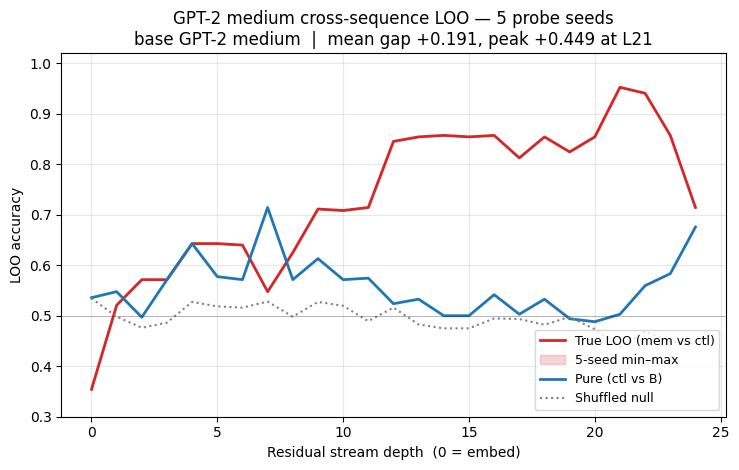

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(7.5, 4.8))
depths = np.arange(NUM_LAYERS)

ax.plot(depths, true_mean, color='C3', lw=2, label='True LOO (mem vs ctl)')
ax.fill_between(depths, true_min, true_max, color='C3', alpha=0.2, label='5-seed min–max')
ax.plot(depths, pure_mean, color='C0', lw=2, label='Pure (ctl vs B)')
ax.plot(depths, shuf_mean, color='gray', lw=1.5, ls=':', label='Shuffled null')
ax.axhline(0.5, color='k', lw=0.5, alpha=0.3)
ax.set_xlabel('Residual stream depth  (0 = embed)'); ax.set_ylabel('LOO accuracy')
ax.set_title(f'GPT-2 medium cross-sequence LOO — 5 probe seeds\n'
             f'{model_label}  |  mean gap {trans_gap_mean:+.3f}, peak {peak_gap:+.3f} at L{peak_depth}')
ax.set_ylim(0.3, 1.02); ax.legend(loc='lower right', fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / f'fig_multiseed_gpt2m_{suffix}.pdf')
plt.savefig(FIGURE_DIR / f'fig_multiseed_gpt2m_{suffix}.png', dpi=150)
plt.show()

## 9. Comparison vs `R1_results.json` (single-seed paper values)

Loads your existing single-seed results if present, builds a per-depth delta table, and produces an overlay figure. Skipped if `R1_results.json` wasn't found in Section 0.

In [14]:
comparison = None

if R1_PATH is not None:
    with open(R1_PATH) as f:
        R1 = json.load(f)

    # R1 stores per-depth dicts under loo_true / loo_pure with 'mean' field.
    # Depths are string keys '0'..'24'.
    R1_depths     = sorted([int(d) for d in R1['loo_true'].keys()])
    R1_true_means = np.array([R1['loo_true'][str(d)]['mean'] for d in R1_depths])
    R1_pure_means = np.array([R1['loo_pure'][str(d)]['mean'] for d in R1_depths])
    R1_gap        = R1_true_means - R1_pure_means

    # Align depth ranges (R1 and multi-seed should match NUM_LAYERS for same model)
    assert len(R1_depths) == NUM_LAYERS, (
        f'depth mismatch: R1 has {len(R1_depths)}, multi-seed has {NUM_LAYERS}'
    )

    comparison = {
        'source_R1_path': str(R1_PATH),
        'R1_trans_gap_mean':    float(R1_gap[1:].mean()),
        'multi_trans_gap_mean': float(trans_gap_mean),
        'delta_trans_gap':      float(trans_gap_mean - R1_gap[1:].mean()),
        'R1_peak_gap':      float(R1_gap[1:].max()),
        'R1_peak_depth':    int(np.argmax(R1_gap[1:])) + 1,
        'multi_peak_gap':   float(peak_gap),
        'multi_peak_depth': peak_depth,
        'per_depth': [
            {'depth': d,
             'R1_true':      float(R1_true_means[d]),
             'R1_pure':      float(R1_pure_means[d]),
             'R1_gap':       float(R1_gap[d]),
             'multi_true':   float(true_mean[d]),
             'multi_pure':   float(pure_mean[d]),
             'multi_gap':    float(gap_mean[d]),
             'delta_true':   float(true_mean[d] - R1_true_means[d]),
             'delta_gap':    float(gap_mean[d] - R1_gap[d])}
            for d in range(NUM_LAYERS)
        ],
    }

    with open(ARTIFACT_DIR / f'loo_comparison_R1_{suffix}.json', 'w') as f:
        json.dump(comparison, f, indent=2)
    print(f'R1_trans_gap_mean:    {comparison["R1_trans_gap_mean"]:+.3f}')
    print(f'multi_trans_gap_mean: {comparison["multi_trans_gap_mean"]:+.3f}')
    print(f'delta                : {comparison["delta_trans_gap"]:+.4f}')
    print(f'R1 peak: {comparison["R1_peak_gap"]:+.3f} @ L{comparison["R1_peak_depth"]}   '
          f'multi peak: {comparison["multi_peak_gap"]:+.3f} @ L{comparison["multi_peak_depth"]}')
else:
    print('R1_results.json not found — skipping comparison. '
          'Upload it as a Kaggle dataset and re-run to populate this section.')

R1_trans_gap_mean:    +0.191
multi_trans_gap_mean: +0.191
delta                : +0.0000
R1 peak: +0.449 @ L21   multi peak: +0.449 @ L21


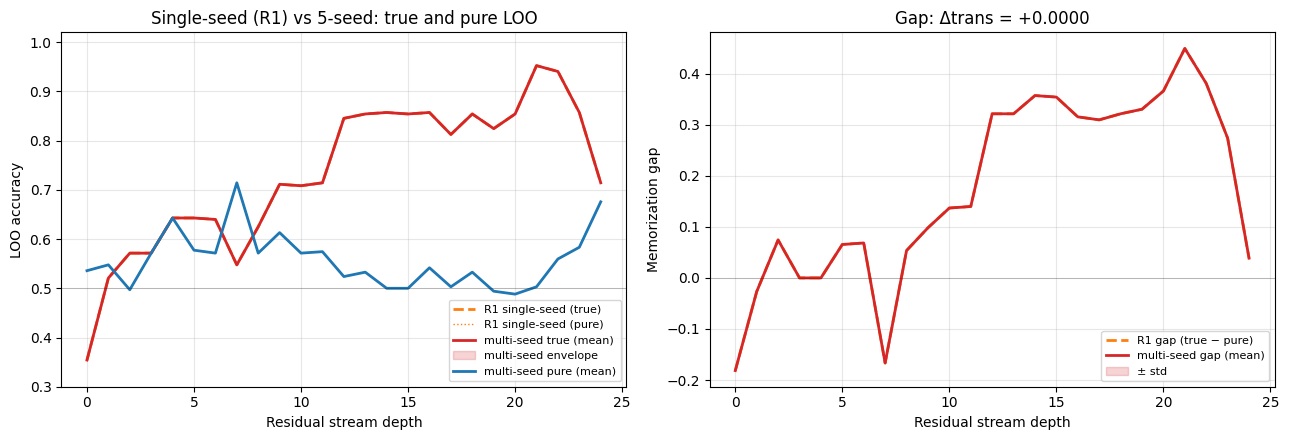

In [15]:
# Overlay figure — R1 single-seed vs multi-seed envelope
if comparison is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    ax = axes[0]
    ax.plot(depths, R1_true_means, color='C1', lw=2, ls='--', label='R1 single-seed (true)')
    ax.plot(depths, R1_pure_means, color='C1', lw=1, ls=':', label='R1 single-seed (pure)')
    ax.plot(depths, true_mean,     color='C3', lw=2,           label='multi-seed true (mean)')
    ax.fill_between(depths, true_min, true_max, color='C3', alpha=0.2, label='multi-seed envelope')
    ax.plot(depths, pure_mean,     color='C0', lw=2,           label='multi-seed pure (mean)')
    ax.axhline(0.5, color='k', lw=0.5, alpha=0.3)
    ax.set_xlabel('Residual stream depth'); ax.set_ylabel('LOO accuracy')
    ax.set_title('Single-seed (R1) vs 5-seed: true and pure LOO')
    ax.set_ylim(0.3, 1.02); ax.legend(loc='lower right', fontsize=8); ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.plot(depths, R1_gap,   color='C1', lw=2, ls='--', label='R1 gap (true − pure)')
    ax.plot(depths, gap_mean, color='C3', lw=2,           label='multi-seed gap (mean)')
    ax.fill_between(depths, gap_mean - gap_std, gap_mean + gap_std,
                    color='C3', alpha=0.2, label='± std')
    ax.axhline(0.0, color='k', lw=0.5, alpha=0.3)
    ax.set_xlabel('Residual stream depth'); ax.set_ylabel('Memorization gap')
    ax.set_title(f'Gap: Δtrans = {comparison["delta_trans_gap"]:+.4f}')
    ax.legend(loc='lower right', fontsize=8); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f'fig_multiseed_comparison_{suffix}.png', dpi=150)
    plt.savefig(FIGURE_DIR / f'fig_multiseed_comparison_{suffix}.pdf')
    plt.show()

## 10. Per-sequence heatmap (rows = sequences, cols = depths)

Directly visualizes cluster-specificity: rows should light up red in the legal block and sit at chance for code/placeholder rows. Values are 5-seed means.

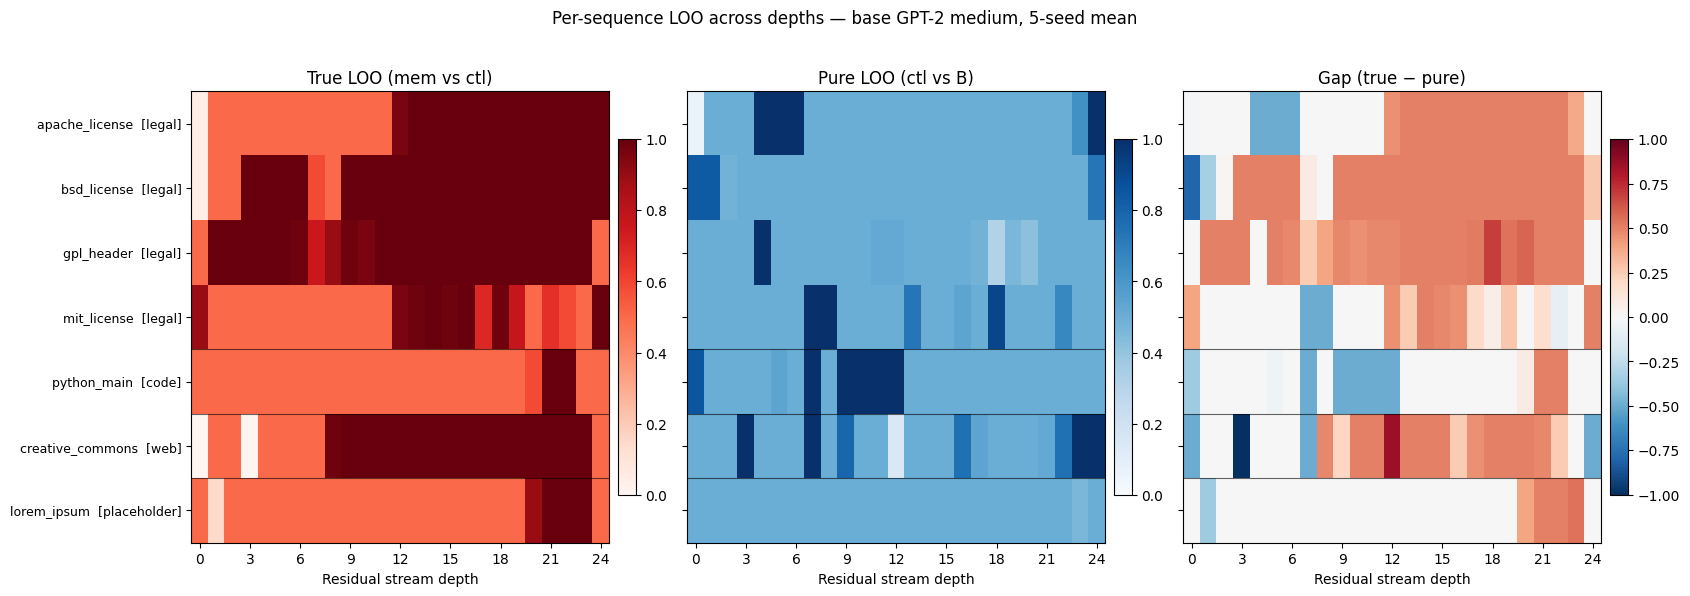

In [16]:
# Sort rows by cluster, then by key name within cluster
row_order = sorted(range(len(VALID_KEYS)),
                   key=lambda i: (CLUSTER_ORDER.index(CLUSTERS[i]) if CLUSTERS[i] in CLUSTER_ORDER else 99,
                                  VALID_KEYS[i]))
sorted_keys     = [VALID_KEYS[i] for i in row_order]
sorted_clusters = [CLUSTERS[i]   for i in row_order]

# Mean across seeds: (NUM_LAYERS, N) → (N, NUM_LAYERS) after transpose, then permute rows
heat_true = results_true.mean(axis=0).T[row_order]
heat_pure = results_pure.mean(axis=0).T[row_order]
heat_gap  = heat_true - heat_pure

fig, axes = plt.subplots(1, 3, figsize=(17, 0.4 * len(sorted_keys) + 3.0), sharey=True)
panels = [
    ('True LOO (mem vs ctl)',  heat_true, 0.0, 1.0, 'Reds'),
    ('Pure LOO (ctl vs B)',    heat_pure, 0.0, 1.0, 'Blues'),
    ('Gap (true − pure)',      heat_gap, None, None, 'RdBu_r'),
]

for ax, (title, mat, vmin, vmax, cmap) in zip(axes, panels):
    if vmin is None:
        vmax_abs = float(np.abs(mat).max())
        norm = TwoSlopeNorm(vmin=-vmax_abs, vcenter=0.0, vmax=vmax_abs)
        im = ax.imshow(mat, aspect='auto', cmap=cmap, norm=norm)
    else:
        im = ax.imshow(mat, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel('Residual stream depth')
    ax.set_xticks(np.arange(0, NUM_LAYERS, max(1, NUM_LAYERS // 8)))
    fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)

# Row labels on the left axis
axes[0].set_yticks(np.arange(len(sorted_keys)))
axes[0].set_yticklabels([f'{k}  [{c}]' for k, c in zip(sorted_keys, sorted_clusters)], fontsize=9)

# Horizontal separators between clusters
cluster_boundaries = []
for i in range(1, len(sorted_clusters)):
    if sorted_clusters[i] != sorted_clusters[i - 1]:
        cluster_boundaries.append(i - 0.5)
for ax in axes:
    for y in cluster_boundaries:
        ax.axhline(y, color='k', lw=0.8, alpha=0.6)

fig.suptitle(f'Per-sequence LOO across depths — {model_label}, 5-seed mean', y=1.02)
plt.tight_layout()
plt.savefig(FIGURE_DIR / f'fig_multiseed_per_sequence_heatmap_{suffix}.png', dpi=150, bbox_inches='tight')
plt.savefig(FIGURE_DIR / f'fig_multiseed_per_sequence_heatmap_{suffix}.pdf', bbox_inches='tight')
plt.show()

## 11. Per-cluster bar chart at peak depth

At the peak-gap layer (L21), break LOO accuracy down by sequence cluster (legal-license, web-prose, code, placeholder/lorem). The cluster-specificity claim — strong for legal/web, near-chance for code/lorem — is what this plot visualizes. Error bars are min–max across seeds × sequences-in-cluster.


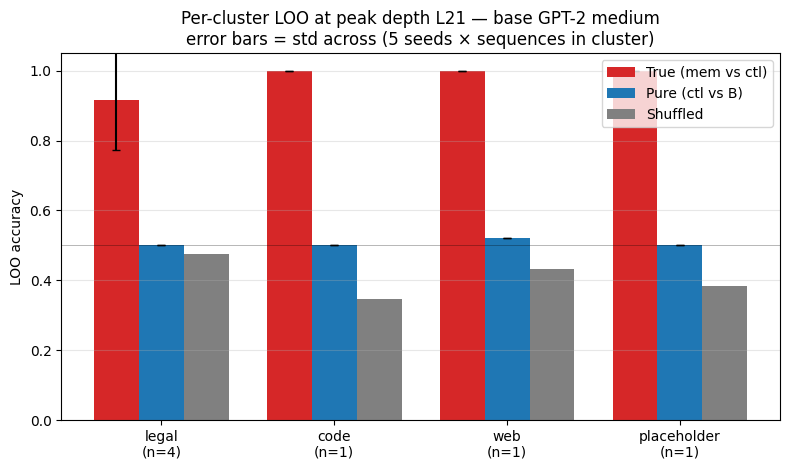

per-cluster stats at peak depth:
  legal         n=4  true=0.917±0.144  pure=0.500±0.000
  code          n=1  true=1.000±0.000  pure=0.500±0.000
  web           n=1  true=1.000±0.000  pure=0.521±0.000
  placeholder   n=1  true=1.000±0.000  pure=0.500±0.000


In [17]:
# For each cluster, collect LOO values at peak depth across (seeds × sequences in cluster)
cluster_stats = {}
for c in CLUSTER_ORDER:
    idx = [i for i, cc in enumerate(CLUSTERS) if cc == c]
    if not idx:
        continue
    true_vals = results_true[:, peak_depth, idx].reshape(-1)   # (seeds × sequences,)
    pure_vals = results_pure[:, peak_depth, idx].reshape(-1)
    shuf_vals = results_shuf[:, peak_depth, idx].reshape(-1)
    cluster_stats[c] = {
        'n_sequences': len(idx),
        'n_points':    int(len(true_vals)),
        'true_mean':   float(true_vals.mean()),
        'true_std':    float(true_vals.std()),
        'pure_mean':   float(pure_vals.mean()),
        'pure_std':    float(pure_vals.std()),
        'shuf_mean':   float(shuf_vals.mean()),
    }

clusters_present = list(cluster_stats.keys())
x = np.arange(len(clusters_present))
w = 0.26

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(x - w, [cluster_stats[c]['true_mean'] for c in clusters_present], w,
       yerr=[cluster_stats[c]['true_std'] for c in clusters_present],
       label='True (mem vs ctl)', color='C3', capsize=3)
ax.bar(x,     [cluster_stats[c]['pure_mean'] for c in clusters_present], w,
       yerr=[cluster_stats[c]['pure_std'] for c in clusters_present],
       label='Pure (ctl vs B)',  color='C0', capsize=3)
ax.bar(x + w, [cluster_stats[c]['shuf_mean'] for c in clusters_present], w,
       label='Shuffled',         color='gray')

ax.axhline(0.5, color='k', lw=0.5, alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels([f'{c}\n(n={cluster_stats[c]["n_sequences"]})' for c in clusters_present])
ax.set_ylabel('LOO accuracy'); ax.set_ylim(0.0, 1.05)
ax.set_title(f'Per-cluster LOO at peak depth L{peak_depth} — {model_label}\n'
             f'error bars = std across (5 seeds × sequences in cluster)')
ax.legend(loc='upper right'); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / f'fig_multiseed_per_cluster_bars_{suffix}.png', dpi=150)
plt.savefig(FIGURE_DIR / f'fig_multiseed_per_cluster_bars_{suffix}.pdf')
plt.show()

print('per-cluster stats at peak depth:')
for c, s in cluster_stats.items():
    print(f'  {c:12s}  n={s["n_sequences"]}  true={s["true_mean"]:.3f}±{s["true_std"]:.3f}  '
          f'pure={s["pure_mean"]:.3f}±{s["pure_std"]:.3f}')

## 12. Seed-by-seed panel (small-multiples)

One small subplot per seed showing the LOO trajectory across layers. The panels serve as a transparency check on whether any single seed drives the result.


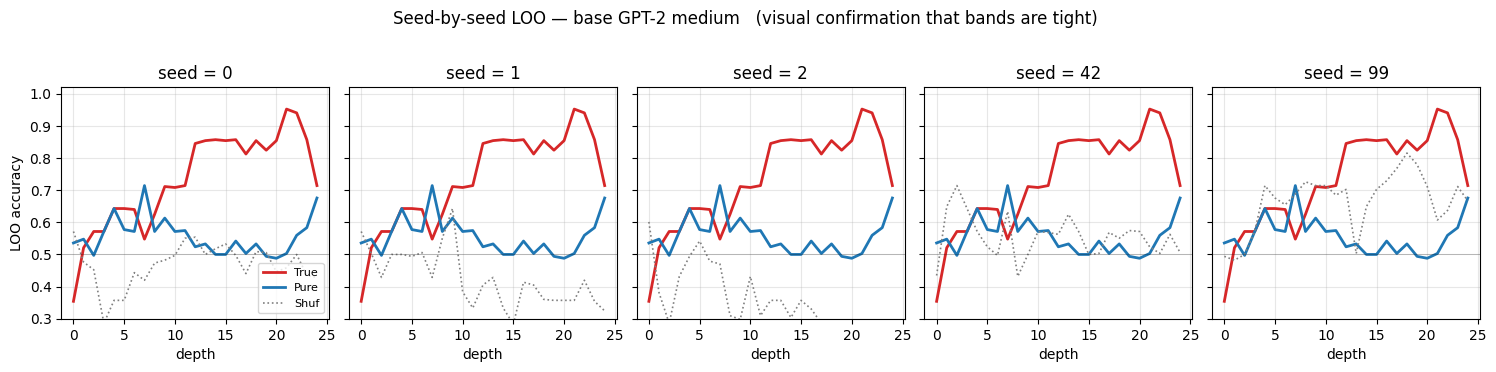

In [18]:
fig, axes = plt.subplots(1, len(SEEDS), figsize=(3.0 * len(SEEDS), 3.6), sharey=True)
for si, (seed, ax) in enumerate(zip(SEEDS, axes)):
    t = results_true[si].mean(axis=1)   # per-depth mean across held-out sequences
    p = results_pure[si].mean(axis=1)
    s = results_shuf[si].mean(axis=1)
    ax.plot(depths, t, color='C3', lw=2, label='True')
    ax.plot(depths, p, color='C0', lw=2, label='Pure')
    ax.plot(depths, s, color='gray', lw=1.2, ls=':', label='Shuf')
    ax.axhline(0.5, color='k', lw=0.5, alpha=0.3)
    ax.set_title(f'seed = {seed}'); ax.set_xlabel('depth')
    ax.set_ylim(0.3, 1.02); ax.grid(True, alpha=0.3)
    if si == 0:
        ax.set_ylabel('LOO accuracy'); ax.legend(loc='lower right', fontsize=8)

fig.suptitle(f'Seed-by-seed LOO — {model_label}   (visual confirmation that bands are tight)',
             y=1.02)
plt.tight_layout()
plt.savefig(FIGURE_DIR / f'fig_multiseed_seed_panel_{suffix}.png', dpi=150, bbox_inches='tight')
plt.savefig(FIGURE_DIR / f'fig_multiseed_seed_panel_{suffix}.pdf', bbox_inches='tight')
plt.show()

## 13. Save JSON + raw tensors

Persists results in two formats: human-readable JSON (`loo_multiseed_{base|unlearned}.json`) for paper-table generation, and raw numpy tensors (`loo_raw_{base|unlearned}.npz`) for downstream notebooks. Both files are picked up by `gpt2m_bootstrap.ipynb` and `gpt2m_jackknife.ipynb`.


In [20]:
output = {
    'config': {
        'model':             MODEL_NAME,
        'use_unlearned_ckpt': USE_UNLEARNED,
        'checkpoint_path':   str(UNLEARNED_CKPT) if USE_UNLEARNED else None,
        'seeds':             SEEDS,
        'num_layers':        int(NUM_LAYERS),
        'd_model':           int(D_MODEL),
        'max_tokens':        MAX_TOKENS,
        'mem_threshold':     MEM_THRESH,
        'ctl_threshold':     CTL_THRESH,
        'valid_keys':        VALID_KEYS,
        'clusters':          CLUSTERS,
        'kaggle':            '/kaggle/working' if IS_KAGGLE else None,
    },
    'screening': screening,
    'headline': {
        'transformer_layer_gap_mean':        trans_gap_mean,
        'transformer_layer_gap_seed_std':    trans_gap_std,
        'peak_gap_mean':                     peak_gap,
        'peak_gap_seed_std':                  peak_seed_std,
        'peak_depth':                        peak_depth,
        'peak_envelope_seed_level':          list(peak_envelope_seed),
        'per_seed_trans_gap':                trans_gap_per_seed.tolist(),
        'per_seed_peak_gap':                 peak_gap_per_seed.tolist(),
        'shuffled_null_mean':                float(results_shuf.mean()),
        'max_per_depth_seed_level_gap_std':  float(gap_std.max()),
    },
    'per_depth': {
        'true_mean': true_mean.tolist(), 'true_std': true_std.tolist(),
        'true_min':  true_min.tolist(),  'true_max': true_max.tolist(),
        'pure_mean': pure_mean.tolist(), 'pure_std': pure_std.tolist(),
        'shuf_mean': shuf_mean.tolist(),
        'gap_mean':  gap_mean.tolist(),  'gap_std':  gap_std.tolist(),
    },
    'per_cluster_at_peak_depth': cluster_stats,
    'comparison_to_R1':          comparison,
    'raw_results_shape':         list(results_true.shape),
}

json_path = ARTIFACT_DIR / f'loo_multiseed_{suffix}.json'
with open(json_path, 'w') as f:
    json.dump(output, f, indent=2)

np.savez(ARTIFACT_DIR / f'loo_raw_{suffix}.npz',
         results_true=results_true,
         results_pure=results_pure,
         results_shuf=results_shuf)

print('artifacts:')
for p in sorted(ARTIFACT_DIR.iterdir()):
    print(f'  {p.name}  ({p.stat().st_size / 1e6:.2f} MB)')
print('figures:')
for p in sorted(FIGURE_DIR.iterdir()):
    print(f'  {p.name}  ({p.stat().st_size / 1e6:.2f} MB)')

artifacts:
  activations_base.npz  (48.07 MB)
  loo_comparison_R1_base.json  (0.01 MB)
  loo_multiseed_base.json  (0.02 MB)
  loo_raw_base.npz  (0.02 MB)
figures:
  fig_multiseed_comparison_base.pdf  (0.02 MB)
  fig_multiseed_comparison_base.png  (0.14 MB)
  fig_multiseed_gpt2m_base.pdf  (0.02 MB)
  fig_multiseed_gpt2m_base.png  (0.10 MB)
  fig_multiseed_per_cluster_bars_base.pdf  (0.02 MB)
  fig_multiseed_per_cluster_bars_base.png  (0.05 MB)
  fig_multiseed_per_sequence_heatmap_base.pdf  (0.03 MB)
  fig_multiseed_per_sequence_heatmap_base.png  (0.10 MB)
  fig_multiseed_seed_panel_base.pdf  (0.02 MB)
  fig_multiseed_seed_panel_base.png  (0.17 MB)


## 14. Paper-integration snippet

Drop-in replacement for §8.2 headline paragraph — fill in the bold values from `artifacts/loo_multiseed_base.json`.

> Across 5 probe seeds ({0, 1, 2, 42, 99}), the memorization-specific gap averages **+X.XXX** across transformer layers and peaks at **+Y.YYY** at L**Z**. The 5-seed min–max envelope at the peak depth spans **[A.AAA, B.BBB]**. Per-seed variation is essentially zero (max per-depth gap std **W.WWWW**), consistent with L2-regularized logistic regression converging to a global optimum on the available training folds — confirming the reported gap is not an artifact of probe-initialization randomness.